In [1]:
import sys

project_path = '/content/drive/MyDrive/credit_score_project'

if project_path not in sys.path:
    sys.path.append(project_path)

In [2]:
import kagglehub
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split
import my_module.custom_transformers as cst
import joblib
sklearn.set_config(transform_output = 'pandas')


In [3]:
german_dataset_raw =pd.read_csv('/content/drive/MyDrive/credit_score_project/datasets_cleaned/German_CR_cleaned.csv',index_col='Unnamed: 0')
german_df = german_dataset_raw.copy()

In [ ]:
german_df.info()
# we have null values in columns Saving account and Checking account
# As no basic cleaning require we can move to train test split and then can perform imputation and encoding.
num_cols = ['Age','Credit amount','Duration']
cat_cols = ['Sex','Job','Housing','Saving accounts','Checking account','Purpose']
target_col = ['Risk']

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 85.9+ KB


/tmp/ipython-input-300509371.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  corr_df['Risk'] = corr_df['Risk'].map({'bad':0,'good':1})


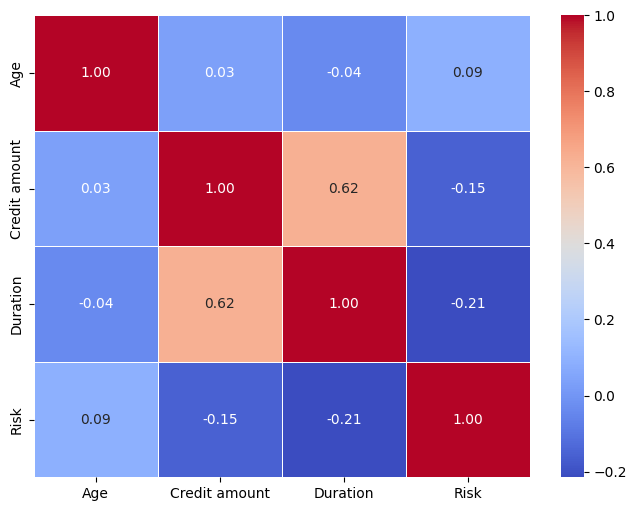

In [ ]:
corr_df = german_df[num_cols+target_col]
corr_df['Risk'] = corr_df['Risk'].map({'bad':0,'good':1})

corr_matrix = corr_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt=".2f",linewidths=0.5)
plt.show()

# from the correlartion we can see that there is no significant correlations
# that can cause problems later in algorithms. %%

array([[<Axes: title={'center': 'Age'}>, <Axes: title={'center': 'Job'}>],
       [<Axes: title={'center': 'Credit amount'}>,
        <Axes: title={'center': 'Duration'}>]], dtype=object)

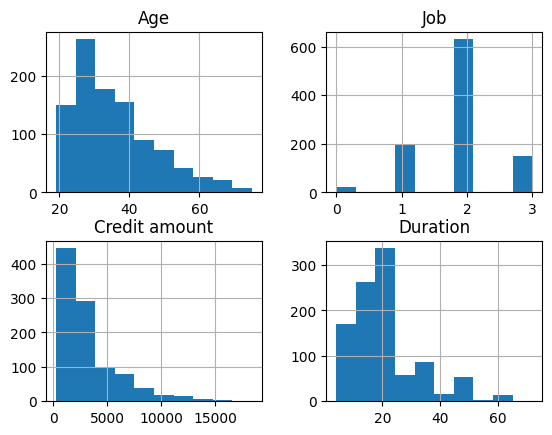

In [ ]:
german_df.hist()

# Data does look rght skwed we can transform it with log later (sqrt probably)

In [ ]:
X = german_df.drop(columns=['Risk'])
y = german_df['Risk'].map({'bad':0,'good':1})

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state = 42)

print(y_train.sum()/len(y_train))
print(y_test.sum()/len(y_test))

0.7
0.7


In [ ]:
X_train.isnull().sum()

,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,149
Checking account,323
Credit amount,0
Duration,0
Purpose,0


In [ ]:
X_train['Checking account'].value_counts()
# it is clear to me that here we can't just impute most frequent category

,count
Checking account,
little,225
moderate,201
rich,51


In [ ]:
print(pd.crosstab(X_train['Saving accounts'],y_train,dropna=False))
print(pd.crosstab(X_train['Checking account'],y_train,dropna=False))

# we can see that there is some relation between missigness and target variable. we can use missigness as a category to use that information.

Risk               0    1
Saving accounts          
little           174  306
moderate          26   61
quite rich         9   39
rich               4   32
NaN               27  122
Risk                0    1
Checking account          
little            110  115
moderate           80  121
rich               12   39
NaN                38  285


In [ ]:
X_train[num_cols].head()

,Age,Credit amount,Duration
675,26,4530,30
703,41,2503,30
12,22,1567,12
845,35,3976,21
795,22,2301,9


In [ ]:
sklearn.set_config(transform_output = 'pandas')

X_train['Saving accounts'] = X_train['Saving accounts'].fillna('Missing')
X_train['Checking account'] = X_train['Checking account'].fillna('Missing')

# Same can be acheived by encoded_missing_value = 0 and +1 - I guess

ord_cat_cols = ['Saving accounts','Checking account','Housing']
ohe_cat_cols = ['Sex','Purpose']

ordinal = OrdinalEncoder()
one_hot = OneHotEncoder(drop = 'first', sparse_output=False)

X_train_ohe = one_hot.fit_transform(X_train[ohe_cat_cols])
X_train_ord = ordinal.fit_transform(X_train[ord_cat_cols])

X_train_encoded = pd.concat([X_train_ord,X_train_ohe,X_train[num_cols]],axis=1)
print(X_train_encoded)

     Saving accounts  Checking account  Housing  Sex_male  Purpose_car  \
675              1.0               0.0      2.0       0.0          0.0   
703              2.0               2.0      1.0       1.0          0.0   
12               1.0               2.0      1.0       0.0          0.0   
845              0.0               2.0      1.0       1.0          0.0   
795              2.0               0.0      2.0       0.0          0.0   
..               ...               ...      ...       ...          ...   
284              2.0               2.0      1.0       1.0          1.0   
169              1.0               2.0      1.0       1.0          0.0   
856              0.0               0.0      1.0       0.0          0.0   
655              1.0               1.0      0.0       1.0          1.0   
695              3.0               0.0      2.0       1.0          1.0   

     Purpose_domestic appliances  Purpose_education  \
675                          0.0                0.0   
7

In [ ]:
X_train_encoded.isnull().sum()


,0
Saving accounts,0
Checking account,0
Housing,0
Sex_male,0
Purpose_car,0
Purpose_domestic appliances,0
Purpose_education,0
Purpose_furniture/equipment,0
Purpose_radio/TV,0
Purpose_repairs,0


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X = add_constant(X_train_encoded)
vif_data = pd.DataFrame()

vif_data['VIF'] = [variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
vif_data['variable'] = X.columns
print(vif_data)

# we are getting inf for Purpose columns so need to change the drop strategy to 'first'

          VIF                     variable
0   45.848750                        const
1    1.027326              Saving accounts
2    1.011415             Checking account
3    1.167467                      Housing
4    1.108978                     Sex_male
5    3.098708                  Purpose_car
6    1.114099  Purpose_domestic appliances
7    1.552053            Purpose_education
8    2.502456  Purpose_furniture/equipment
9    2.948637             Purpose_radio/TV
10   1.247371              Purpose_repairs
11   1.125412      Purpose_vacation/others
12   1.132391                          Age
13   1.847205                Credit amount
14   1.766104                     Duration


In [ ]:
X_train_encoded.head()

,Saving accounts,Checking account,Housing,Sex_male,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others,Age,Credit amount,Duration
675,1.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,26,4530,30
703,2.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,41,2503,30
12,1.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,22,1567,12
845,0.0,2.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,35,3976,21
795,2.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,22,2301,9


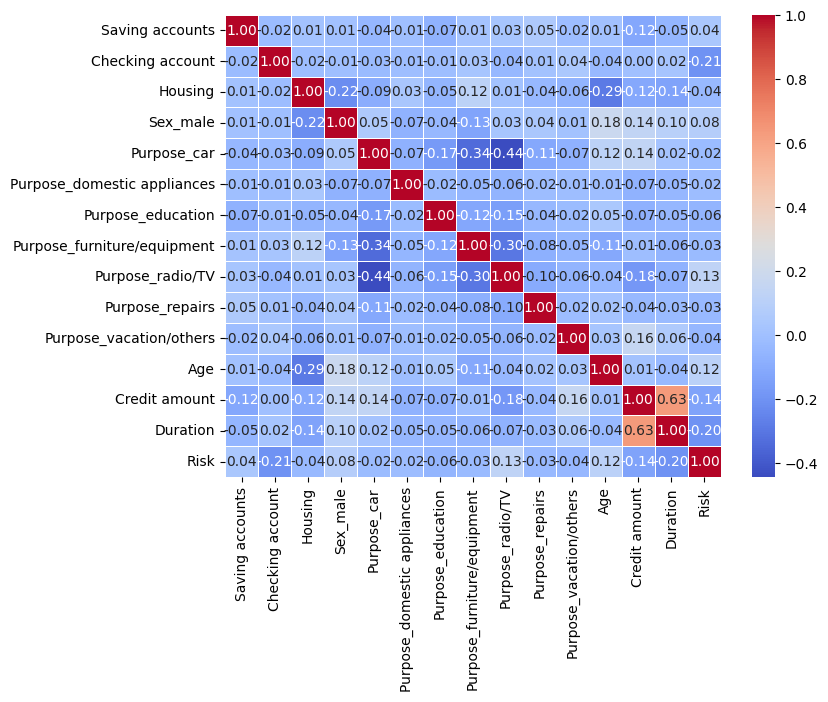

In [ ]:
corr_df = pd.concat([X_train_encoded,y_train],axis=1)

corr_matrix = corr_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt=".2f",linewidths=0.5)
plt.show()

# it can be seen that there does not seem to be multicolinarity cases.
#The only thing to notice is that duration and credit amount are strongly
#related that also seem fair

array([[<Axes: title={'center': 'Saving accounts'}>,
        <Axes: title={'center': 'Checking account'}>,
        <Axes: title={'center': 'Housing'}>,
        <Axes: title={'center': 'Sex_male'}>],
       [<Axes: title={'center': 'Purpose_car'}>,
        <Axes: title={'center': 'Purpose_domestic appliances'}>,
        <Axes: title={'center': 'Purpose_education'}>,
        <Axes: title={'center': 'Purpose_furniture/equipment'}>],
       [<Axes: title={'center': 'Purpose_radio/TV'}>,
        <Axes: title={'center': 'Purpose_repairs'}>,
        <Axes: title={'center': 'Purpose_vacation/others'}>,
        <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Credit amount'}>,
        <Axes: title={'center': 'Duration'}>, <Axes: >, <Axes: >]],
      dtype=object)

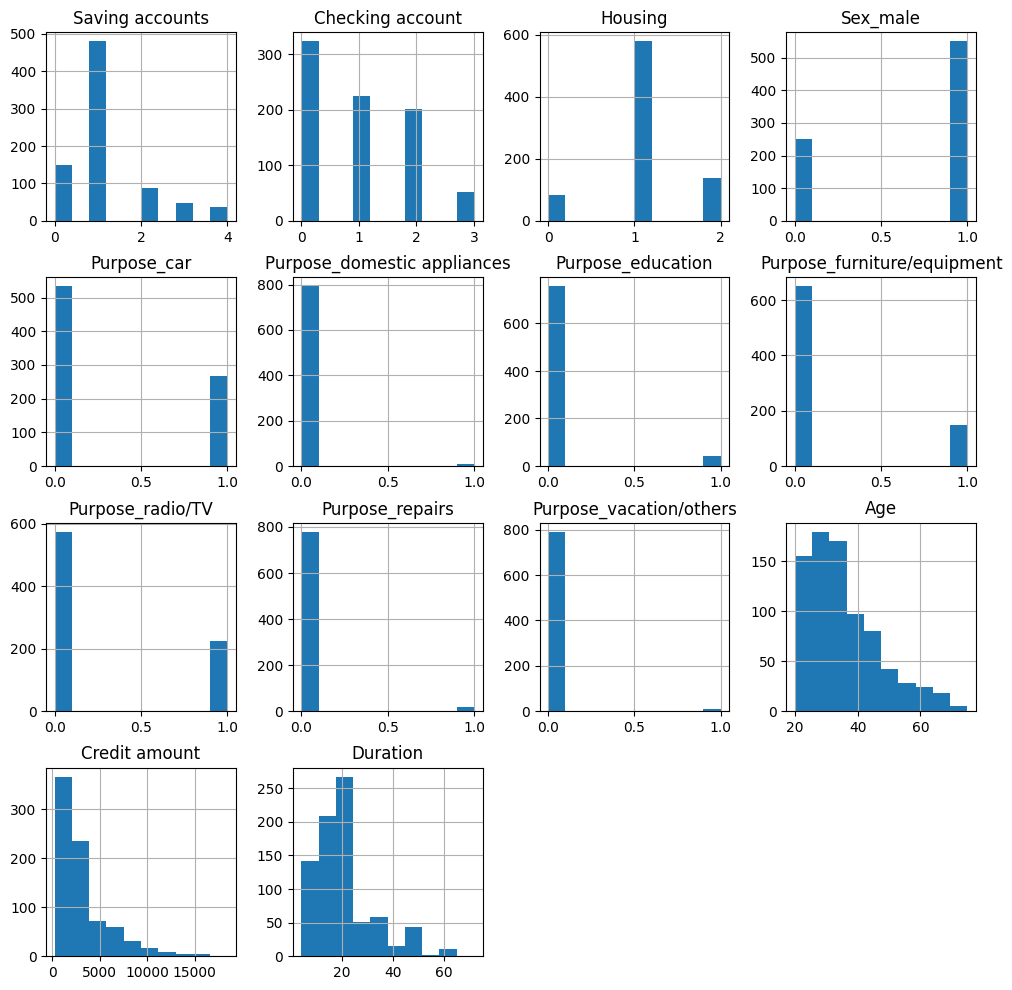

In [ ]:
X_train_encoded.hist(figsize=(12,12))

In [ ]:
## Lets first make preprocessing pipeline so that we can use it as we want with other models.

In [3]:
num_cols = ['Age','Credit amount','Duration']
cat_cols = ['Sex','Job','Housing','Saving accounts','Checking account','Purpose']
target_col = ['Risk']
ord_cat_cols = ['Saving accounts','Checking account','Housing']
ohe_cat_cols = ['Sex','Purpose']
missing_cols = ['Saving accounts','Checking account']
drop_cols = ['Unnamed: 0']

scaler = Pipeline(steps=[
    ("log transform",FunctionTransformer(np.log1p, validate=False)),
    ("std_scaler", StandardScaler())
])

encoder_scaler = ColumnTransformer(transformers=[
    ("ordinal",OrdinalEncoder(),ord_cat_cols),
     ("onehot",OneHotEncoder(drop = 'first', sparse_output=False),ohe_cat_cols),
      ("scaler", scaler, num_cols)
], remainder='drop')

preprocess_pipeline = Pipeline(steps=[
     ("missing_imputer", cst.missingcategory(columns_to_fill=missing_cols,missing_label='Missing')),
      ("Encoder", encoder_scaler),
        ('renamer',cst.renamer())

])

In [5]:
# joblib.dump(preprocess_pipeline, "/content/drive/MyDrive/credit_score_project/preprocessing/german_cr_preprocess_v1.joblib")

['/content/drive/MyDrive/credit_score_project/preprocessing/german_cr_preprocess_v1.joblib']

In [4]:
# X = german_df.drop(columns=['Risk'])
# y = german_df['Risk'].map({'bad':0,'good':1})

# X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state = 42)

# print(y_train.sum()/len(y_train))
# print(y_test.sum()/len(y_test))


0.7
0.7


In [13]:
# X_train_preprocessed = preprocess_pipeline.fit_transform(X_train)
# feature_names = preprocess_pipeline.get_feature_names_out
# X_test_preprocessed = preprocess_pipeline.transform(X_test)
# X_train_preprocessed.head()

,ordinal__Saving accounts,ordinal__Checking account,ordinal__Housing,onehot__Sex_male,onehot__Purpose_car,onehot__Purpose_domestic appliances,onehot__Purpose_education,onehot__Purpose_furniture/equipment,onehot__Purpose_radio/TV,onehot__Purpose_repairs,onehot__Purpose_vacation/others,numeric__Age,numeric__Credit amount,numeric__Duration
675,-0.186225,-1.022429,1.783509,-1.48324,-0.70777,-0.100504,-0.241249,-0.480384,1.598611,-0.160128,-0.100504,-0.874701,0.847376,0.906740
703,0.862929,1.074861,-0.136824,0.67420,-0.70777,-0.100504,-0.241249,-0.480384,-0.625543,-0.160128,-0.100504,0.644893,0.082595,0.906740
12,-0.186225,1.074861,-0.136824,-1.48324,-0.70777,-0.100504,-0.241249,-0.480384,1.598611,-0.160128,-0.100504,-1.426168,-0.521035,-0.672812
845,-1.235378,1.074861,-0.136824,0.67420,-0.70777,-0.100504,-0.241249,2.081666,-0.625543,-0.160128,-0.100504,0.114723,0.679197,0.283408
795,0.862929,-1.022429,1.783509,-1.48324,-0.70777,-0.100504,-0.241249,2.081666,-0.625543,-0.160128,-0.100504,-1.426168,-0.025872,-1.149681


array([[<Axes: title={'center': 'ordinal__Saving accounts'}>,
        <Axes: title={'center': 'ordinal__Checking account'}>,
        <Axes: title={'center': 'ordinal__Housing'}>,
        <Axes: title={'center': 'onehot__Sex_male'}>],
       [<Axes: title={'center': 'onehot__Purpose_car'}>,
        <Axes: title={'center': 'onehot__Purpose_domestic appliances'}>,
        <Axes: title={'center': 'onehot__Purpose_education'}>,
        <Axes: title={'center': 'onehot__Purpose_furniture/equipment'}>],
       [<Axes: title={'center': 'onehot__Purpose_radio/TV'}>,
        <Axes: title={'center': 'onehot__Purpose_repairs'}>,
        <Axes: title={'center': 'onehot__Purpose_vacation/others'}>,
        <Axes: title={'center': 'numeric__Age'}>],
       [<Axes: title={'center': 'numeric__Credit amount'}>,
        <Axes: title={'center': 'numeric__Duration'}>, <Axes: >,
        <Axes: >]], dtype=object)

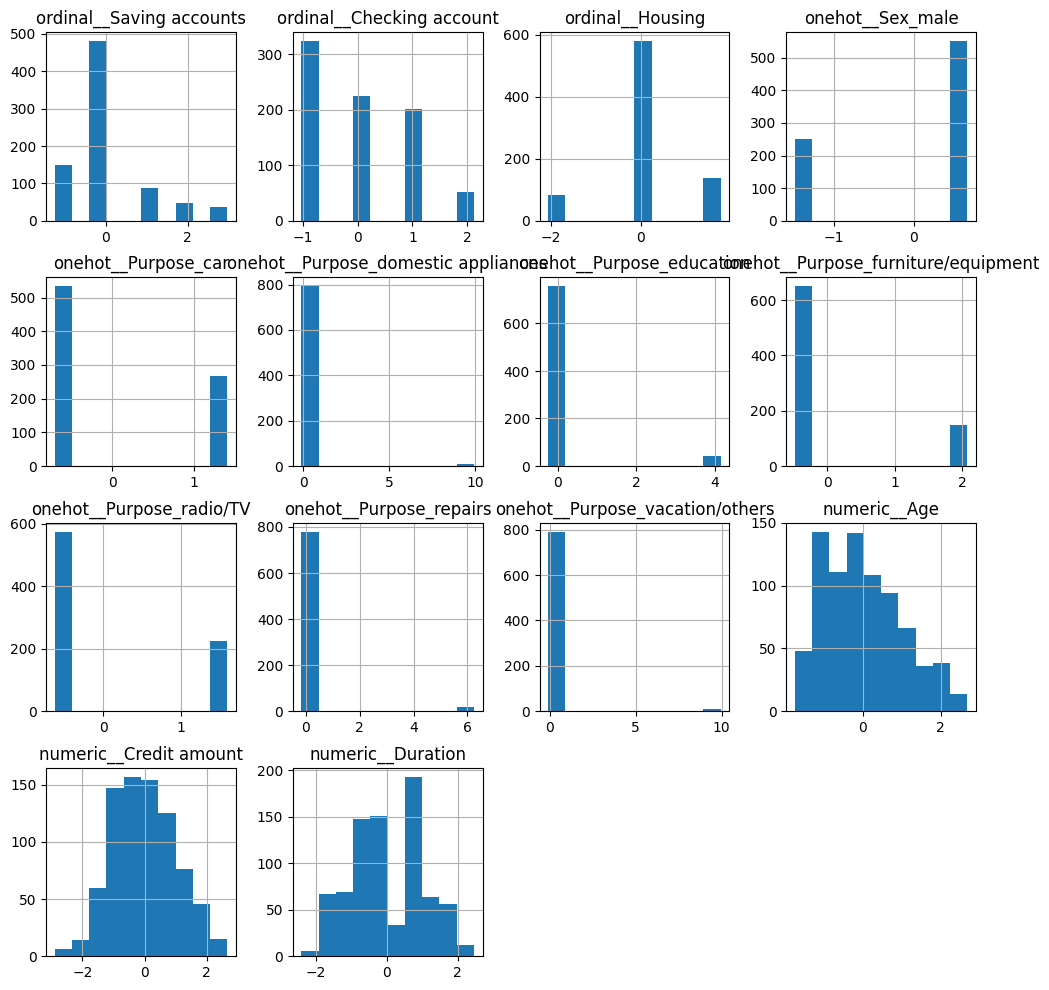

In [14]:
# X_train_preprocessed.hist(figsize=(12,12))

In [ ]:
# Now after the prepocessing pipeline is completed we can go ahead and use the
# pipleline for different models. first we will starts with logistic regression


In [4]:
preprocess_pipeline

Pipeline(steps=[('missing_imputer',
                 missingcategory(columns_to_fill=['Saving accounts',
                                                  'Checking account'],
                                 missing_label='Missing')),
                ('Encoder',
                 ColumnTransformer(transformers=[('ordinal', OrdinalEncoder(),
                                                  ['Saving accounts',
                                                   'Checking account',
                                                   'Housing']),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                sparse_output=False),
                                                  ['Sex', 'Purpose']),
                                                 ('scaler',
                                                  Pipeline(steps=[('log '
                                                                   'transform',
                                                                   FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                  ('std_scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Credit amount',
                                                   'Duration'])])),
                ('renamer', renamer())])